# 04 – Performance Analytics
**Bluestock Fintech Mutual Fund Analytics Platform**

Covers: CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Max Drawdown, Rolling metrics, Benchmark comparison, and Fund Ranking Scorecard.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
BASE = Path("..").resolve()
PROC = BASE / "data" / "processed"
RPT  = BASE / "reports"
sys.path.insert(0, str(BASE / "scripts"))

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

nav   = pd.read_csv(PROC / "nav_history_clean.csv",       parse_dates=["date"])
sp    = pd.read_csv(PROC / "scheme_performance_clean.csv")
bench = pd.read_csv(PROC / "benchmark_indices_clean.csv", parse_dates=["date"])
master= pd.read_csv(PROC / "fund_master_clean.csv")
print("Data loaded.")

Data loaded.


## 1. Compute Full Fund Scorecard

In [2]:
from compute_metrics import compute_fund_scorecard
scorecard = compute_fund_scorecard(nav, bench)
scorecard = scorecard.merge(sp[["amfi_code","scheme_name","fund_house","category","risk_grade"]], on="amfi_code", how="left")
scorecard.to_csv(PROC / "fund_scorecard.csv", index=False)
print(f"Scorecard: {len(scorecard)} funds")
print(scorecard[["scheme_name","cagr_pct","sharpe_ratio","sortino_ratio","max_drawdown_pct","beta","alpha_pct"]].head(10).to_string(index=False))

Scorecard: 40 funds
                                       scheme_name  cagr_pct  sharpe_ratio  sortino_ratio  max_drawdown_pct  beta  alpha_pct
         HDFC Top 100 Fund - Regular Plan - Growth      2.64       -0.2015        -0.3482            -24.73   NaN        NaN
      HDFC Short Term Debt Fund - Regular - Growth      4.46       -0.5671        -0.9154             -4.31   NaN        NaN
HDFC Mid-Cap Opportunities Fund - Regular - Growth     30.12        1.0937         1.8238            -16.22   NaN        NaN
     ABSL Frontline Equity Fund - Regular - Growth     23.54        1.0272         1.7856            -11.29   NaN        NaN
            ABSL Small Cap Fund - Regular - Growth      7.94        0.1627         0.2746            -35.45   NaN        NaN
               ABSL Liquid Fund - Regular - Growth      6.51       -0.8156        -1.3246             -0.16   NaN        NaN
        UTI Nifty 50 Index Fund - Regular - Growth     18.23        0.8171         1.4182            -10.

## 2. CAGR Distribution

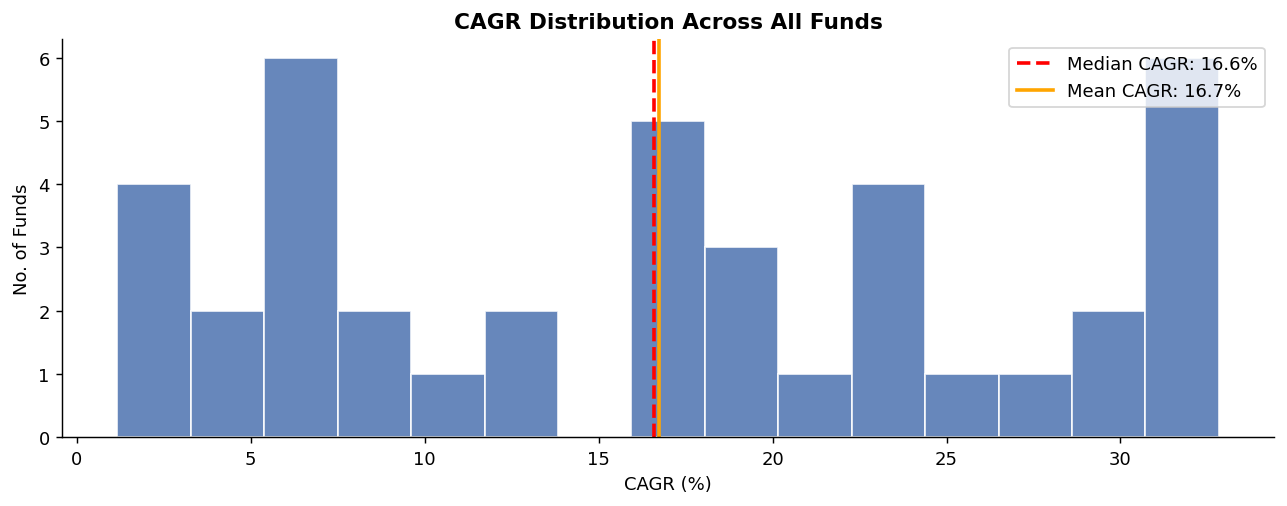

In [3]:
fig, ax = plt.subplots(figsize=(10,4))
valid = scorecard["cagr_pct"].dropna()
ax.hist(valid, bins=15, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(valid.median(), color="red", linestyle="--", linewidth=2, label=f"Median CAGR: {valid.median():.1f}%")
ax.axvline(valid.mean(),   color="orange", linestyle="-", linewidth=2, label=f"Mean CAGR: {valid.mean():.1f}%")
ax.set_title("CAGR Distribution Across All Funds", fontweight="bold")
ax.set_xlabel("CAGR (%)"); ax.set_ylabel("No. of Funds")
ax.legend()
plt.tight_layout()
plt.savefig(RPT / "chart_pa01_cagr_dist.png", dpi=150)
plt.show()

## 3. Sharpe Ratio vs CAGR (Risk-Return Scatter)

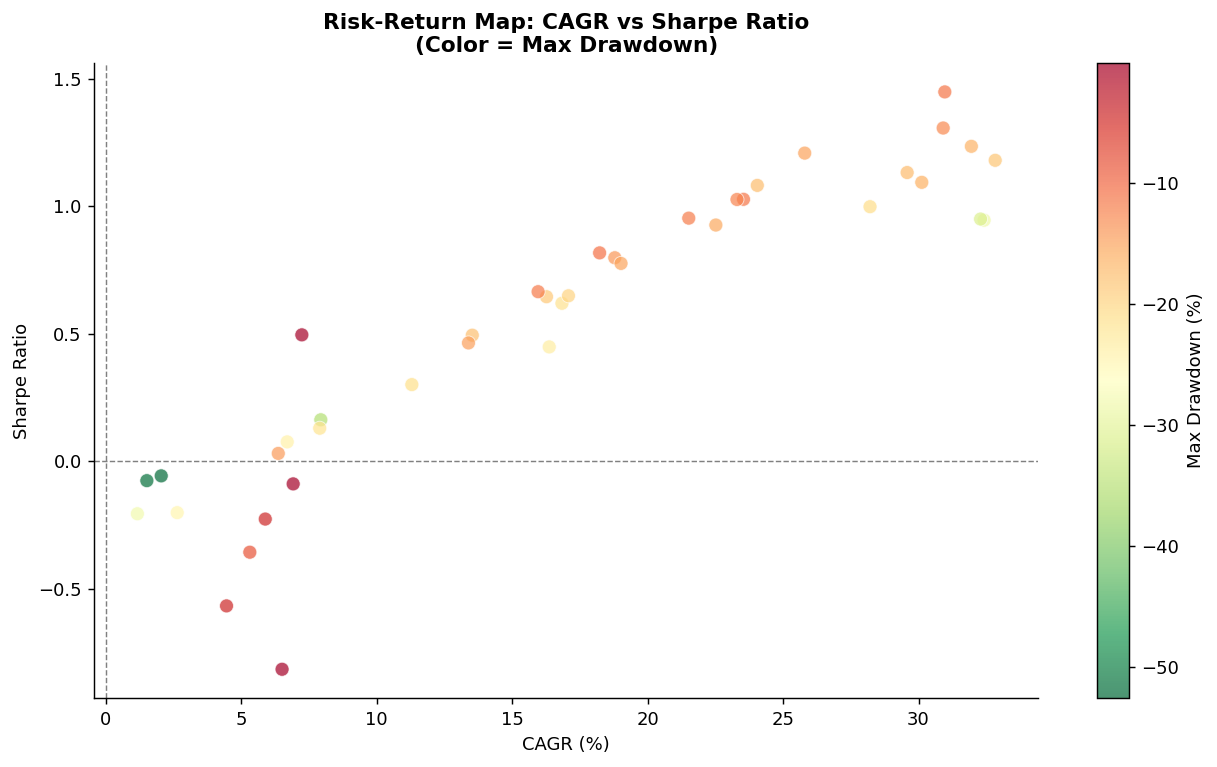

In [4]:
fig, ax = plt.subplots(figsize=(10,6))
data = scorecard.dropna(subset=["cagr_pct","sharpe_ratio"])
scatter = ax.scatter(data["cagr_pct"], data["sharpe_ratio"],
                     c=data["max_drawdown_pct"], cmap="RdYlGn_r",
                     s=60, alpha=0.7, edgecolors="white", linewidth=0.5)
plt.colorbar(scatter, ax=ax, label="Max Drawdown (%)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("Risk-Return Map: CAGR vs Sharpe Ratio\n(Color = Max Drawdown)", fontweight="bold")
ax.set_xlabel("CAGR (%)"); ax.set_ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(RPT / "chart_pa02_risk_return_scatter.png", dpi=150)
plt.show()

## 4. Top 10 Funds by Sharpe Ratio

Top 10 Funds by Sharpe Ratio:
                                           scheme_name  sharpe_ratio  sortino_ratio  cagr_pct  max_drawdown_pct
1        Mirae Asset Large Cap Fund - Regular - Growth        1.4483         2.3683     30.97            -11.27
2               Kotak Flexicap Fund - Regular - Growth        1.3067         2.3529     30.91            -12.97
3        Mirae Asset Tax Saver Fund - Regular - Growth        1.2349         2.1351     31.95            -16.40
4            SBI Bluechip Fund - Regular Plan - Growth        1.2083         2.1040     25.80            -15.01
5             ICICI Pru Midcap Fund - Regular - Growth        1.1801         2.0100     32.83            -18.19
6                   DSP Midcap Fund - Regular - Growth        1.1321         1.8689     29.58            -17.25
7   HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937         1.8238     30.12            -16.22
8       Nippon India Large Cap Fund - Regular - Growth        1.0817      

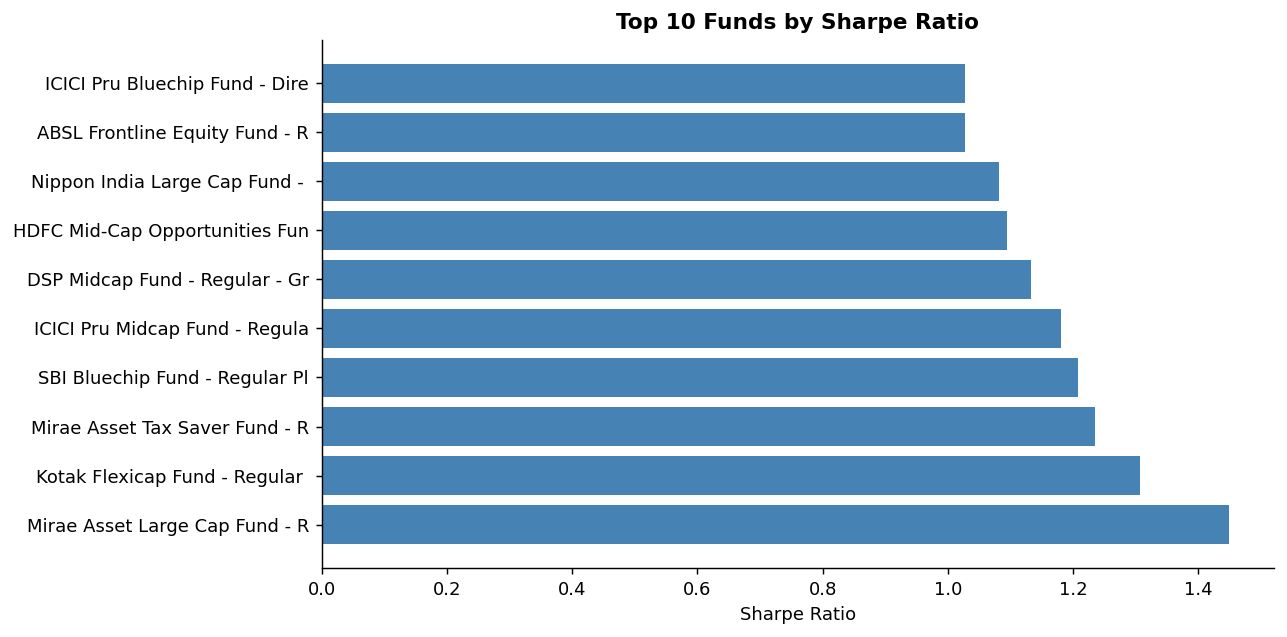

In [5]:
top_sharpe = scorecard.nlargest(10, "sharpe_ratio")[["scheme_name","sharpe_ratio","sortino_ratio","cagr_pct","max_drawdown_pct"]].reset_index(drop=True)
top_sharpe.index += 1
print("Top 10 Funds by Sharpe Ratio:")
print(top_sharpe.to_string())
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(top_sharpe["scheme_name"].str[:30], top_sharpe["sharpe_ratio"], color="steelblue")
ax.set_title("Top 10 Funds by Sharpe Ratio", fontweight="bold")
ax.set_xlabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(RPT / "chart_pa03_top_sharpe.png", dpi=150)
plt.show()

## 5. Max Drawdown Analysis

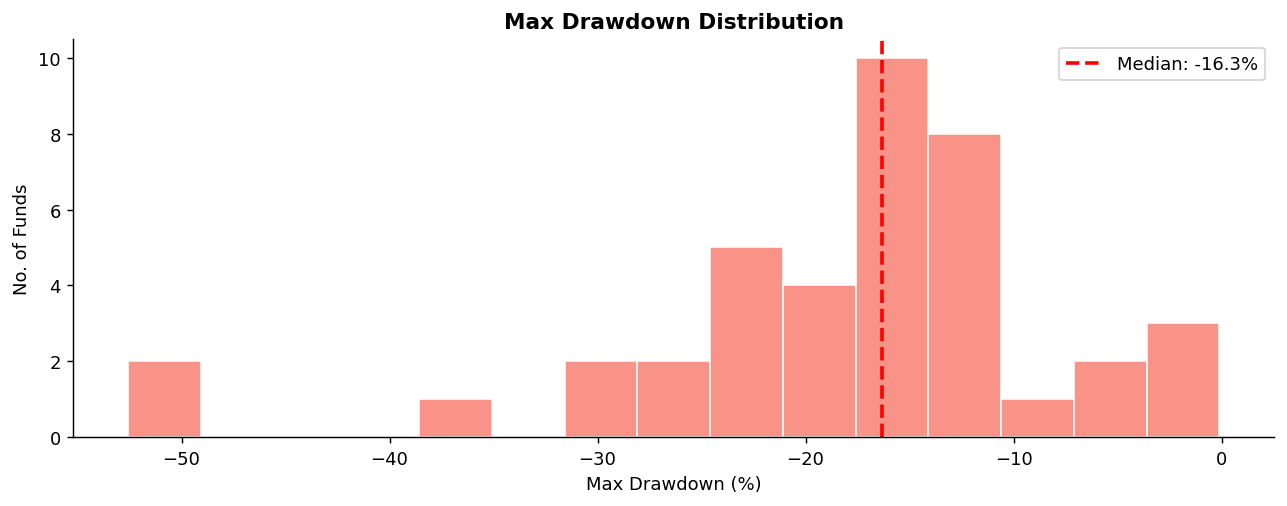

In [6]:
fig, ax = plt.subplots(figsize=(10,4))
dd_data = scorecard["max_drawdown_pct"].dropna()
ax.hist(dd_data, bins=15, color="salmon", edgecolor="white", alpha=0.85)
ax.axvline(dd_data.median(), color="red", linestyle="--", linewidth=2, label=f"Median: {dd_data.median():.1f}%")
ax.set_title("Max Drawdown Distribution", fontweight="bold")
ax.set_xlabel("Max Drawdown (%)"); ax.set_ylabel("No. of Funds")
ax.legend()
plt.tight_layout()
plt.savefig(RPT / "chart_pa04_max_drawdown.png", dpi=150)
plt.show()

## 6. NAV Drawdown – Single Fund Walk-Through

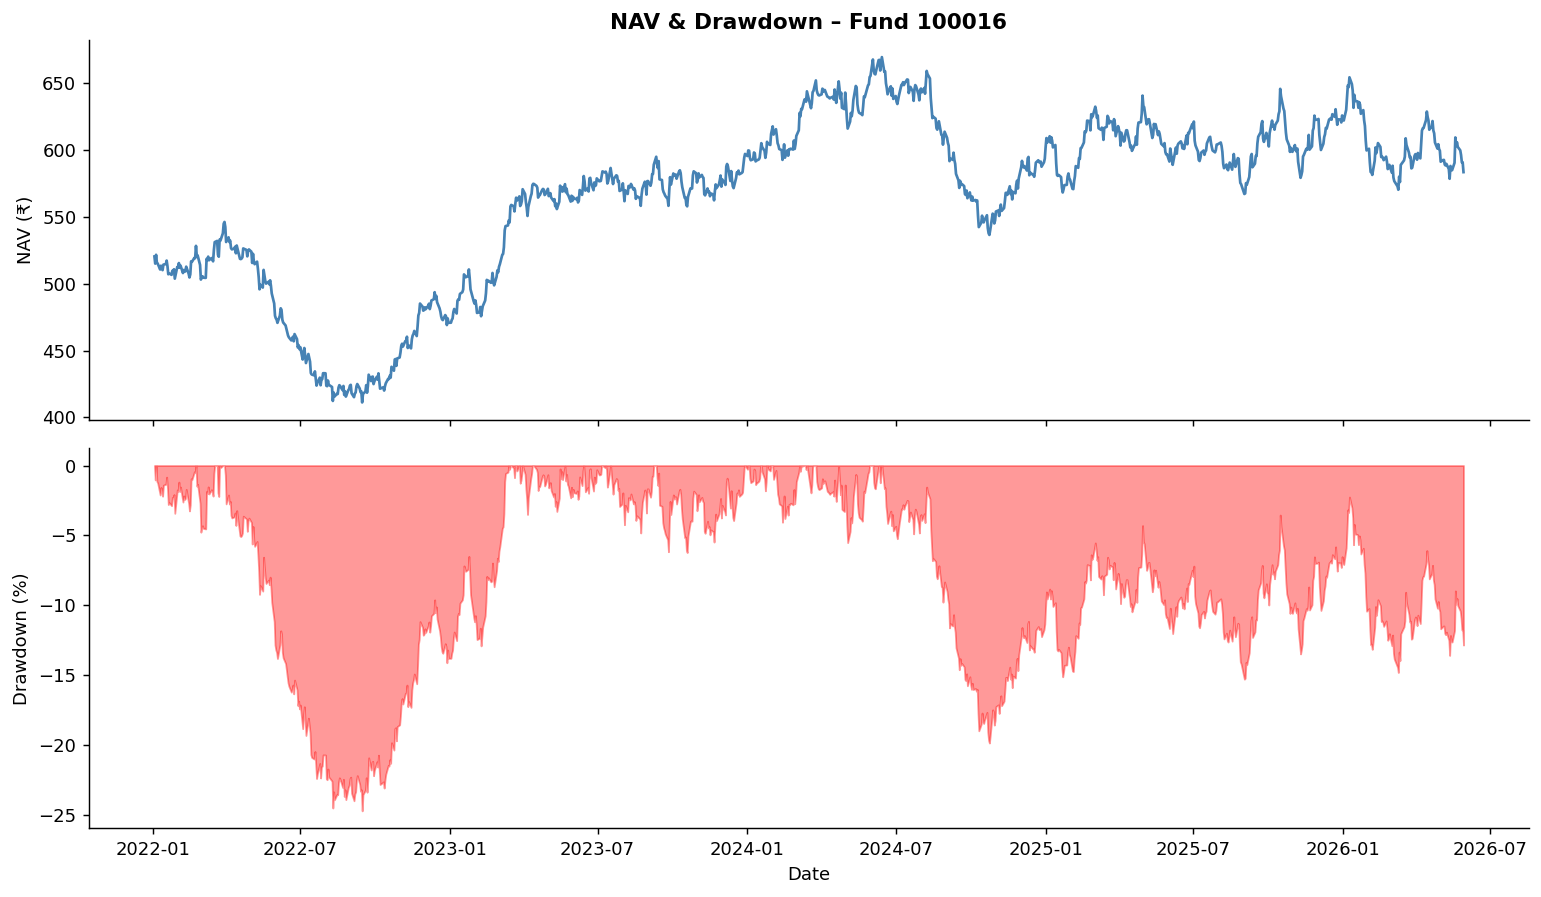

In [7]:
sample_code = nav["amfi_code"].value_counts().idxmax()
grp = nav[nav["amfi_code"]==sample_code].sort_values("date").set_index("date")
navs = grp["nav"]
rolling_max = navs.cummax()
drawdown = (navs - rolling_max) / rolling_max * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,7), sharex=True)
ax1.plot(navs.index, navs, color="steelblue", linewidth=1.5)
ax1.set_title(f"NAV & Drawdown – Fund {sample_code}", fontweight="bold")
ax1.set_ylabel("NAV (₹)")
ax2.fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.4)
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig(RPT / "chart_pa05_drawdown_analysis.png", dpi=150)
plt.show()

## 7. Rolling Sharpe Ratio

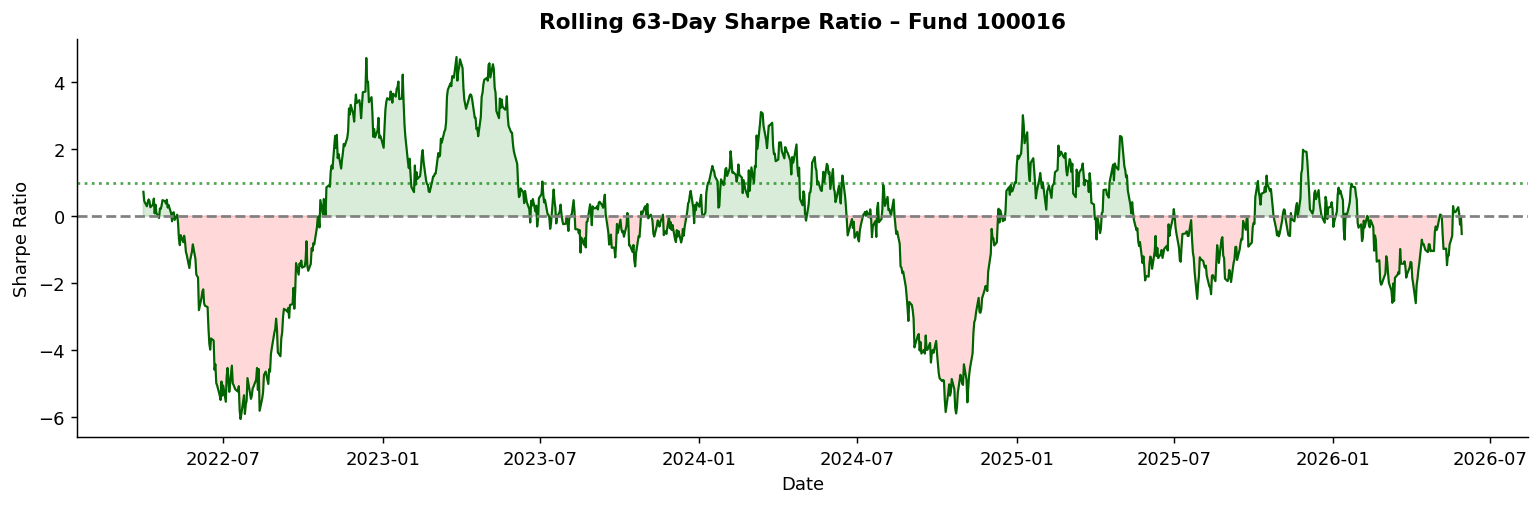

In [8]:
from compute_metrics import rolling_sharpe
sample_nav = nav[nav["amfi_code"]==sample_code].sort_values("date").set_index("date")
roll_sh = rolling_sharpe(sample_nav["daily_return_pct"], window=63)
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(roll_sh.index, roll_sh, color="darkgreen", linewidth=1.2)
ax.axhline(0, color="gray", linestyle="--")
ax.axhline(1, color="green", linestyle=":", alpha=0.7)
ax.fill_between(roll_sh.index, roll_sh, 0, where=(roll_sh>0), color="green", alpha=0.15)
ax.fill_between(roll_sh.index, roll_sh, 0, where=(roll_sh<0), color="red",   alpha=0.15)
ax.set_title(f"Rolling 63-Day Sharpe Ratio – Fund {sample_code}", fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(RPT / "chart_pa06_rolling_sharpe.png", dpi=150)
plt.show()

## 8. Alpha vs Beta Scatter (All Funds)

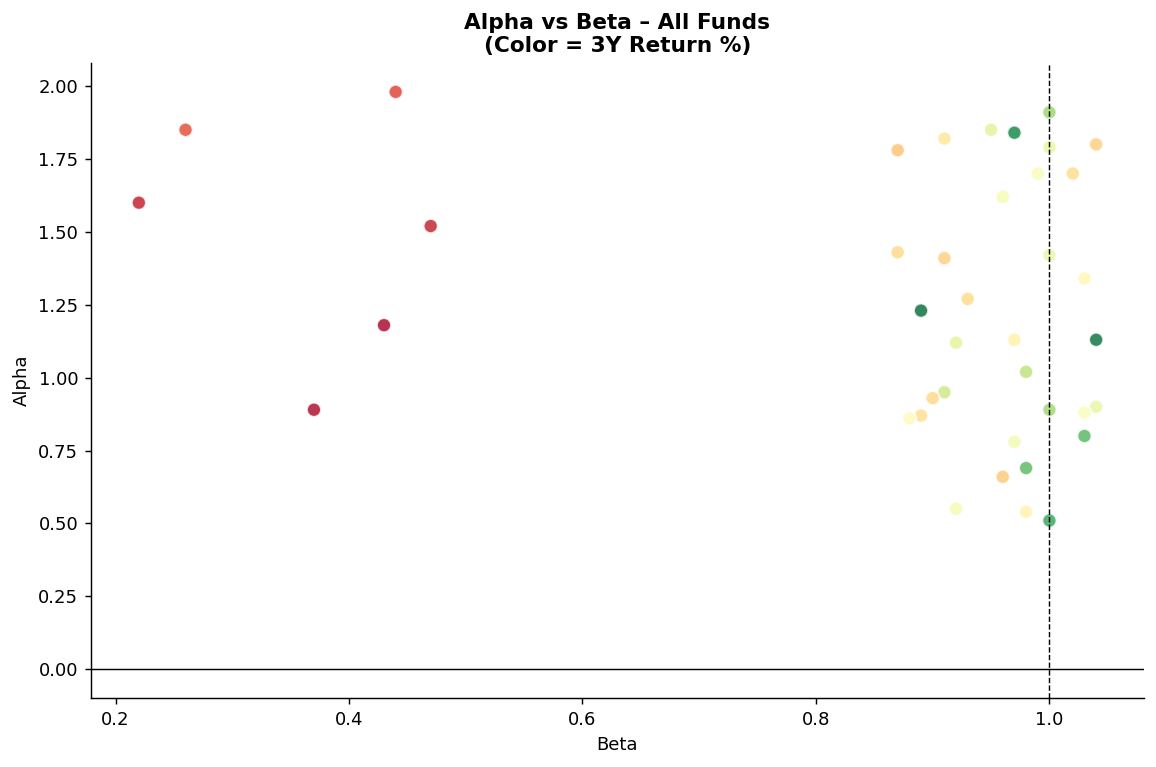

In [9]:
sp_ab = sp.dropna(subset=["alpha","beta"])
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(sp_ab["beta"], sp_ab["alpha"],
           c=sp_ab["return_3yr_pct"], cmap="RdYlGn",
           s=60, alpha=0.8, edgecolors="white")
ax.axhline(0, color="black", linewidth=0.8); ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Alpha vs Beta – All Funds\n(Color = 3Y Return %)", fontweight="bold")
ax.set_xlabel("Beta"); ax.set_ylabel("Alpha")
plt.tight_layout()
plt.savefig(RPT / "chart_pa07_alpha_beta.png", dpi=150)
plt.show()

## 9. Fund Ranking Scorecard

In [10]:
sc = scorecard.copy()
def rank_norm(series, ascending=True):
    ranked = series.rank(ascending=ascending, na_option="bottom")
    return ranked / ranked.max()

sc["r_cagr"]     = rank_norm(sc["cagr_pct"])
sc["r_sharpe"]   = rank_norm(sc["sharpe_ratio"])
sc["r_drawdown"] = rank_norm(sc["max_drawdown_pct"], ascending=False)
sc["r_sortino"]  = rank_norm(sc["sortino_ratio"])
sc["composite"]  = (0.35*sc["r_cagr"] + 0.30*sc["r_sharpe"] +
                    0.20*sc["r_drawdown"] + 0.15*sc["r_sortino"])

top10 = sc.nlargest(10, "composite")[["scheme_name","cagr_pct","sharpe_ratio","sortino_ratio",
                                       "max_drawdown_pct","composite"]].reset_index(drop=True)
top10.index += 1
print("\n🏆 Top 10 Fund Ranking Scorecard:")
print(top10.to_string())
top10.to_csv(PROC / "top10_fund_ranking.csv")


🏆 Top 10 Fund Ranking Scorecard:
                                           scheme_name  cagr_pct  sharpe_ratio  sortino_ratio  max_drawdown_pct  composite
1             ICICI Pru Midcap Fund - Regular - Growth     32.83        1.1801         2.0100            -18.19    0.88000
2        Mirae Asset Tax Saver Fund - Regular - Growth     31.95        1.2349         2.1351            -16.40    0.85625
3           SBI Small Cap Fund - Regular Plan - Growth     32.42        0.9453         1.6612            -28.71    0.83250
4                DSP Small Cap Fund - Regular - Growth     32.29        0.9498         1.6071            -31.17    0.82875
5               Kotak Flexicap Fund - Regular - Growth     30.91        1.3067         2.3529            -12.97    0.81000
6        Mirae Asset Large Cap Fund - Regular - Growth     30.97        1.4483         2.3683            -11.27    0.80500
7                   DSP Midcap Fund - Regular - Growth     29.58        1.1321         1.8689            

## 10. Benchmark vs Fund Category Returns

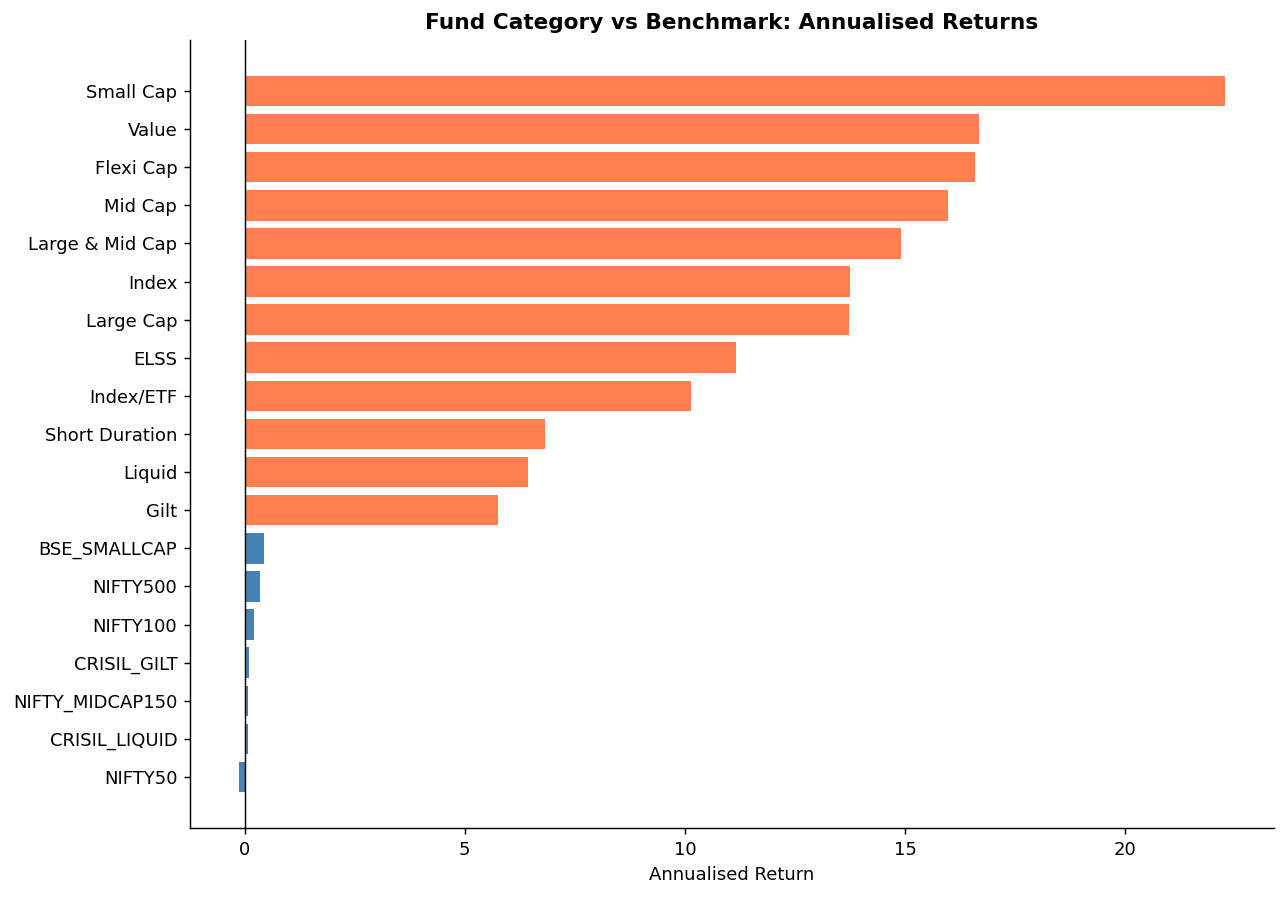

Performance Analytics Notebook Complete


In [11]:
# Benchmark Annualised Returns

bench_returns = {}

for idx, grp in bench.groupby("index_name"):

    returns = (
        grp.sort_values("date")
        .tail(252)["daily_return_pct"]
        .dropna()
    )

    if len(returns) > 0:

        bench_returns[idx] = (
            (1 + returns / 100).prod()
        ) ** (252 / len(returns)) - 1

bench_df = pd.DataFrame(
    list(bench_returns.items()),
    columns=["index", "annualized_return"]
)

# Category Returns
cat_ret = (
    sp.groupby("category")["return_1yr_pct"]
    .mean()
    .reset_index()
)

cat_ret.columns = ["index", "annualized_return"]

# Combine
all_ret = pd.concat(
    [bench_df, cat_ret],
    ignore_index=True
)

all_ret = all_ret.sort_values(
    "annualized_return",
    ascending=True
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    "steelblue"
    if idx in bench_df["index"].values
    else "coral"
    for idx in all_ret["index"]
]

ax.barh(
    all_ret["index"],
    all_ret["annualized_return"],
    color=colors
)

ax.set_title(
    "Fund Category vs Benchmark: Annualised Returns",
    fontweight="bold"
)

ax.set_xlabel("Annualised Return")
ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()

plt.savefig(
    RPT / "chart_pa08_category_vs_benchmark.png",
    dpi=150
)

plt.show()

print("Performance Analytics Notebook Complete")